# Modelagem de um Sistema de Tratamento de Efluentes em Cascata

**Disciplina:** Cálculo Numérico · Engenharia Ambiental  
**Instituição:** UFRPE — DC  

---

> **Como usar este caderno**  
> Leia cada seção de texto com atenção antes de executar as células de código.  
> As células marcadas com 🔧 **Exercício** são para você completar.  
> Execute as células na ordem, de cima para baixo.


## Configuração inicial

Importamos aqui todas as bibliotecas que serão usadas ao longo do caderno.

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec

# Configuração visual padrão
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


---
## 1. Contexto: a planta que você gerencia

Você é o engenheiro responsável pelo tratamento de efluentes de uma indústria de processamento de alimentos. Sua planta gera centenas de metros cúbicos por dia de água residual carregada de matéria orgânica (poluente).

Essa água **não pode** ser lançada no rio sem tratamento: a legislação exige que a concentração de poluente no efluente final seja no máximo **0,5 mg/L**.

O sistema de tratamento consiste em **três tanques biológicos em série** (CSTRs — reatores de mistura completa). Em cada tanque, microrganismos decompõem a matéria orgânica, tornando a água mais limpa a cada etapa.

### O que é eficiência biológica?
A **eficiência biológica** é a capacidade dos microrganismos presentes nos tanques de remover o poluente da água. Quanto maior a eficiência, mais rapidamente o poluente é decomposto. Essa eficiência depende de fatores como temperatura, quantidade de microrganismos, oxigênio disponível e tipo de poluente. Se a eficiência biológica cair (por exemplo, em dias frios ou se houver algum problema com os microrganismos), o sistema pode não conseguir remover o poluente o suficiente para atender à legislação.

---

### Unidades típicas dos parâmetros
- **Vazão (Q):** volume de água tratado por unidade de tempo. Unidade típica: **m³/dia** (metros cúbicos por dia).
- **Concentração de poluente (C):** quantidade de poluente por volume de água. Unidade típica: **mg/L** (miligramas por litro).
- **Volume dos tanques (V):** capacidade de cada tanque. Unidade típica: **m³** (metros cúbicos).

---

### Esquema do sistema de tanques

Abaixo desta célula, você visualiza um esquema visual do sistema de tratamento, mostrando o fluxo da água e a redução do poluente em cada etapa:


- **Q**: Vazão (volume de água por dia)
- **Cin**: Concentração de poluente na entrada
- **V₁, V₂, V₃**: Volumes dos tanques 1, 2 e 3
- **C₁, C₂, C₃**: Concentração de poluente em cada tanque

Como gestor, você precisa responder:

- No funcionamento estável, qual é a concentração final? A planta está dentro da lei?
- Se a eficiência biológica cair, o sistema ainda cumpre o limite?
- Qual é o mínimo de eficiência biológica necessário para manter a conformidade?

Para responder essas perguntas, precisamos de um **modelo matemático**. É o que construiremos agora.


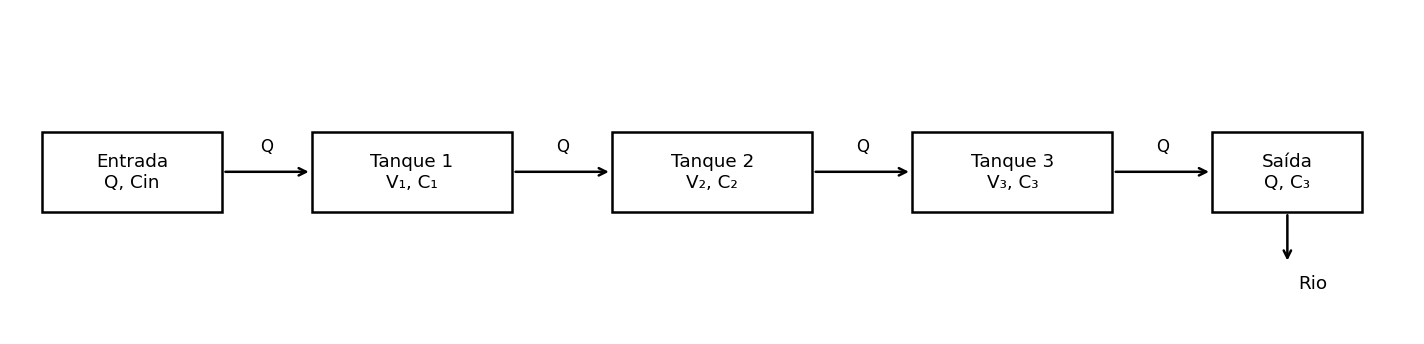

In [52]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(12, 3))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis("off")

def caixa(x, y, w, h, texto):
    rect = Rectangle((x, y), w, h, fill=False, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, texto, ha="center", va="center", fontsize=11)

def seta(x1, y1, x2, y2, rotulo=None):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", linewidth=1.5)
    )
    if rotulo:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.2, rotulo, ha="center", va="bottom", fontsize=10)

caixa(0.3, 1.5, 1.8, 1.0, "Entrada\nQ, Cin")
caixa(3.0, 1.5, 2.0, 1.0, "Tanque 1\nV₁, C₁")
caixa(6.0, 1.5, 2.0, 1.0, "Tanque 2\nV₂, C₂")
caixa(9.0, 1.5, 2.0, 1.0, "Tanque 3\nV₃, C₃")
caixa(12.0, 1.5, 1.5, 1.0, "Saída\nQ, C₃")

ax.text(13.0, 0.6, "Rio", ha="center", va="center", fontsize=11)

seta(2.1, 2.0, 3.0, 2.0, "Q")
seta(5.0, 2.0, 6.0, 2.0, "Q")
seta(8.0, 2.0, 9.0, 2.0, "Q")
seta(11.0, 2.0, 12.0, 2.0, "Q")
seta(12.75, 1.5, 12.75, 0.85, None)

plt.tight_layout()
plt.show()

---
## 2. Parâmetros do sistema

A célula abaixo define os dados de projeto da instalação.
Eles serão usados em todos os cálculos posteriores — se quiser explorar outros cenários, basta alterar os valores aqui.


In [53]:
# ── Parâmetros do sistema ──────────────────────────────────────────────
Q   = 100.0   # Vazão volumétrica            [m³/d]
V1  = 500.0   # Volume do Tanque 1           [m³]
V2  = 400.0   # Volume do Tanque 2           [m³]
V3  = 400.0   # Volume do Tanque 3           [m³]
Cin = 10.0    # Concentração de entrada      [mg/L]
k   = 0.2     # Constante de decaimento      [d⁻¹]
# k representa a eficiência biológica: quanto maior k, mais rápido o poluente é removido pelos microrganismos.
# Seu valor depende da temperatura, do tipo de microrganismo e das condições do tanque.
# (valor inicial; será variado depois)

# Tempo de residência: quanto tempo, em média, uma partícula de água permanece dentro de cada tanque.
# É calculado como o volume do tanque dividido pela vazão: TR = V / Q
# (quanto maior o volume ou menor a vazão, maior o tempo de residência)
TR1 = V1 / Q
TR2 = V2 / Q
TR3 = V3 / Q

print(f"Tempo de residência — Tanque 1: {TR1:.1f} d")
print(f"Tempo de residência — Tanque 2: {TR2:.1f} d")
print(f"Tempo de residência — Tanque 3: {TR3:.1f} d")


Tempo de residência — Tanque 1: 5.0 d
Tempo de residência — Tanque 2: 4.0 d
Tempo de residência — Tanque 3: 4.0 d


---
## 3. O modelo: de onde vem a Equação Diferencial?

### O que é uma EDO?

Antes de escrever as equações, precisamos conversar sobre uma ideia que vai aparecer aqui pela primeira vez
e que acompanhará vocês pelo resto da vida profissional: a **Equação Diferencial Ordinária (EDO)**.

A ideia central é simples. Há grandezas que não são constantes — elas mudam continuamente com o tempo.
E muitas vezes, a **taxa com que elas mudam** depende do próprio valor delas naquele instante.

**Exemplo:** uma xícara de café a 80 °C numa sala a 20 °C esfria mais rápido do que quando já está a 25 °C.
A taxa de resfriamento depende da temperatura atual. Se chamarmos de $T(t)$ a temperatura no instante $t$:

$$\frac{dT}{dt} = -r\,(T - 20)$$

Aqui, $r$ é uma constante positiva que representa a rapidez com que o café troca calor com o ambiente (quanto maior $r$, mais rápido o resfriamento). O sinal negativo indica que, se a temperatura do café $T$ está acima da temperatura ambiente (20 °C), a variação $dT/dt$ será negativa — ou seja, o café vai esfriar. Se, por algum motivo, $T$ estivesse abaixo de 20 °C, a equação indicaria que o café esquentaria, aproximando-se sempre da temperatura ambiente. Esse mecanismo faz com que a temperatura do café se mova em direção ao equilíbrio com o ambiente.

Leia: *"a taxa de variação de $T$ é proporcional à diferença entre $T$ e a temperatura ambiente."*
Essa é uma EDO: uma equação que relaciona uma função desconhecida ($T$) com sua própria derivada ($dT/dt$).

**Resolver** a EDO significa encontrar a função $T(t)$ que satisfaz essa relação — saber a temperatura
em qualquer instante, não apenas como ela está mudando.

---

### A concentração varia com o tempo

No nosso sistema, a grandeza que varia é a **concentração de poluente** em cada tanque: $C_1(t)$, $C_2(t)$, $C_3(t)$.

Quando o sistema é ligado, essas concentrações não assumem instantaneamente seus valores de equilíbrio.
Elas partem de valores iniciais e evoluem até se estabilizar. Essa dinâmica é o que queremos descrever.

---

### O que é balanço de massa? Por que é importante?

O **balanço de massa** é uma ferramenta fundamental da engenharia e das ciências ambientais. Ele se baseia no princípio de que a matéria não pode ser criada nem destruída, apenas transformada ou transferida. Esse é o chamado **princípio de conservação de massa**.

Em termos simples, o balanço de massa diz que:

> **O que entra em um sistema, menos o que sai, mais o que é gerado, menos o que é consumido, resulta na variação do que está dentro do sistema.**

No contexto do nosso problema:
- O sistema são os tanques de tratamento.
- O poluente entra com a água bruta, pode ser removido (degradado) pelos microrganismos, e sai com a água tratada.
- O balanço de massa nos permite escrever equações que descrevem exatamente como a concentração de poluente muda ao longo do tempo em cada tanque.

Por que isso é importante?
- Sem o balanço de massa, não conseguiríamos prever se o sistema atende à legislação ou como ele responde a mudanças (por exemplo, uma queda na eficiência biológica).
- O balanço de massa é a base para construir modelos matemáticos confiáveis, que ajudam a tomar decisões de projeto, operação e controle.

---

### O balanço de massa no Tanque 1

Aplicamos o princípio de conservação de massa no Tanque 1:

$$\frac{d(V_1 C_1)}{dt} = \underbrace{Q\,C_{in}}_{\text{entra}} - \underbrace{Q\,C_1}_{\text{sai}} - \underbrace{k\,V_1\,C_1}_{\text{degradado}}$$

O que essa equação está dizendo? O termo $V_1 C_1$ representa a **quantidade total de poluente** (em mg) presente dentro do Tanque 1 a cada instante. A expressão $\frac{d(V_1 C_1)}{dt}$ é a **derivada temporal** dessa quantidade, ou seja, indica **a velocidade com que a quantidade de poluente dentro do tanque está mudando ao longo do tempo**.

- Se $\frac{d(V_1 C_1)}{dt}$ for positiva, a quantidade de poluente no tanque está aumentando.
- Se for negativa, está diminuindo.
- Se for zero, a quantidade de poluente está constante (regime permanente).

A equação iguala essa variação ao balanço entre o que entra, o que sai e o que é removido por degradação biológica:
- $Q C_{in}$: poluente que entra por unidade de tempo. Isso é uma **taxa de massa** (por exemplo, miligramas por dia, mg/d). $Q$ é a vazão volumétrica (m³/d) e $C_{in}$ é a concentração (mg/L), então $Q C_{in}$ tem unidade de m³/d × mg/L = mg/d × (1 m³ = 1000 L) = 1000 × mg/d. Ou seja, representa a quantidade de massa de poluente que entra no tanque a cada dia.
- $Q C_1$: poluente que sai por unidade de tempo (também uma taxa de massa, mg/d).
- $k V_1 C_1$: poluente removido (degradado) por unidade de tempo (mg/d).

Assim, a equação expressa matematicamente o princípio de conservação de massa: **toda mudança na quantidade de poluente dentro do tanque é explicada pelo que entra, sai e é removido**.

Como $V_1$ é constante, dividimos por $V_1$ e obtemos a EDO do Tanque 1:

$$\frac{dC_1}{dt} = \frac{Q}{V_1}\,C_{in} - \frac{Q}{V_1}\,C_1 - k\,C_1 = \tau_1\,C_{in} - (\tau_1 + k)\,C_1$$

Aqui, $\tau_i = Q/V_i$ é chamado de **taxa de renovação** ou **taxa de diluição** do tanque $i$. Ele indica o quão rapidamente o conteúdo do tanque é renovado pela entrada de água nova. Quanto maior a vazão $Q$ (ou menor o volume $V_i$), maior é $\tau_i$, ou seja, mais rapidamente o tanque é "lavado" pela água que entra. O inverso de $\tau_i$ é o **tempo de residência** ($TR_i = V_i/Q$), que representa quanto tempo, em média, uma partícula de água permanece no tanque.

O mesmo raciocínio se aplica a cada tanque, usando a saída do tanque anterior como entrada:

$$\boxed{\frac{dC_i}{dt} = \tau_i\,C_{i-1} - (\tau_i + k)\,C_i}, \qquad i = 1, 2, 3 \quad (C_0 \equiv C_{in})$$

Leia a EDO: se $C_i$ for pequeno, a entrada domina e a concentração **sobe**; se $C_i$ for grande,
saída e degradação dominam e ela **cai**. Em algum ponto, tudo se equilibra — esse é o regime permanente.

> ⚠️ **Não vamos resolver essas EDOs agora.** Isso exige métodos numéricos (Euler, Runge-Kutta…)
> que estudaremos nos próximos módulos. Por enquanto, exploraremos o **estado de equilíbrio**.


### Visualizando a dinâmica do sistema

A célula abaixo usa o método de Euler (que você estudará em breve) para simular a evolução
das concentrações ao longo do tempo — apenas para que você *veja* o que as EDOs descrevem.
Não se preocupe com o código agora; foque na interpretação do gráfico.


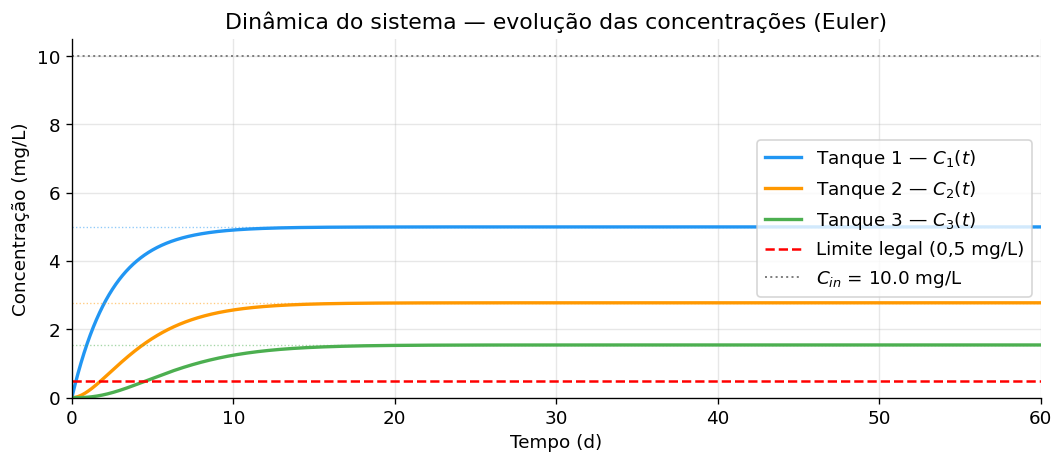


Concentrações em regime permanente (t = 60 d):
  C₁ ≈ 5.0000 mg/L
  C₂ ≈ 2.7778 mg/L
  C₃ ≈ 1.5432 mg/L

Limite legal (0,5 mg/L): ✗ NÃO atendido


In [54]:
def simular_sistema(Q, V1, V2, V3, Cin, k, t_max=60, dt=0.01, C0=(0, 0, 0)):
    """Integra o sistema de 3 EDOs pelo método de Euler explícito."""
    tau1, tau2, tau3 = Q/V1, Q/V2, Q/V3
    t = np.arange(0, t_max + dt, dt)
    C = np.zeros((len(t), 3))
    C[0] = C0

    for n in range(len(t) - 1):
        c1, c2, c3 = C[n]
        dC1 = tau1 * Cin - (tau1 + k) * c1
        dC2 = tau2 * c1  - (tau2 + k) * c2
        dC3 = tau3 * c2  - (tau3 + k) * c3
        C[n+1] = [c1 + dt*dC1, c2 + dt*dC2, c3 + dt*dC3]

    return t, C

t, C = simular_sistema(Q, V1, V2, V3, Cin, k)

fig, ax = plt.subplots(figsize=(9, 4))
cores = ['#2196F3', '#FF9800', '#4CAF50']
rotulos = ['Tanque 1 — $C_1(t)$', 'Tanque 2 — $C_2(t)$', 'Tanque 3 — $C_3(t)$']

for i, (cor, rot) in enumerate(zip(cores, rotulos)):
    ax.plot(t, C[:, i], color=cor, lw=2, label=rot)

ax.axhline(0.5, color='red', ls='--', lw=1.5, label='Limite legal (0,5 mg/L)')
ax.axhline(Cin, color='gray', ls=':', lw=1.2, label=f'$C_{{in}}$ = {Cin} mg/L')

# Marcar regime permanente aproximado
for i, cor in enumerate(cores):
    ax.axhline(C[-1, i], color=cor, ls=':', lw=0.8, alpha=0.5)

ax.set_xlabel('Tempo (d)')
ax.set_ylabel('Concentração (mg/L)')
ax.set_title('Dinâmica do sistema — evolução das concentrações (Euler)')
ax.legend(loc='right')
ax.set_xlim(0, t[-1])
ax.set_ylim(0, Cin * 1.05)
plt.tight_layout()
plt.show()

print(f"\nConcentrações em regime permanente (t = {t[-1]:.0f} d):")
print(f"  C₁ ≈ {C[-1,0]:.4f} mg/L")
print(f"  C₂ ≈ {C[-1,1]:.4f} mg/L")
print(f"  C₃ ≈ {C[-1,2]:.4f} mg/L")
print(f"\nLimite legal (0,5 mg/L): {'✓ atendido' if C[-1,2] <= 0.5 else '✗ NÃO atendido'}")


---
## 4. Parte 1 — Regime permanente: sistema de equações lineares

### Da EDO à álgebra

O sistema opera a maior parte do tempo em **regime permanente**: as concentrações não variam mais.
Matematicamente, impor $dC_i/dt = 0$ elimina as derivadas e transforma as EDOs em equações algébricas:

$$\left(\tau_1 + k\right)C_1 = \tau_1\,C_{in}$$

$$-\tau_2\,C_1 + \left(\tau_2 + k\right)C_2 = 0$$

$$-\tau_3\,C_2 + \left(\tau_3 + k\right)C_3 = 0$$

Na forma matricial $A\mathbf{x} = \mathbf{b}$:

$$\begin{bmatrix} \tau_1+k & 0 & 0 \\ -\tau_2 & \tau_2+k & 0 \\ 0 & -\tau_3 & \tau_3+k \end{bmatrix} \begin{bmatrix} C_1 \\ C_2 \\ C_3 \end{bmatrix} = \begin{bmatrix} \tau_1 C_{in} \\ 0 \\ 0 \end{bmatrix}$$

Note que $A$ é **triangular inferior** — consequência da topologia em série. Isso significa que o sistema
pode ser resolvido por substituição progressiva. Veremos que isso nem sempre acontece (por exemplo, com reciclo).


### 🔧 Exercício 1 — Monte a matriz $A$ e o vetor $\mathbf{b}$

Nosso objetivo aqui é transformar o problema físico dos tanques em série em um sistema de equações lineares, que pode ser resolvido com métodos de álgebra linear. As **incógnitas** desse sistema são as concentrações de poluente em cada tanque no regime permanente: $C_1$, $C_2$ e $C_3$.

Ao montar a matriz $A$ e o vetor $\mathbf{b}$, estamos escrevendo matematicamente as relações de balanço de massa para cada tanque, considerando o regime permanente (quando as concentrações não mudam mais com o tempo).

Ao resolver esse sistema, vamos encontrar os valores de $C_1$, $C_2$ e $C_3$ no estado estacionário, ou seja, quando o sistema já atingiu o equilíbrio. Isso nos permite responder perguntas como: a planta está dentro do limite legal? Qual a eficiência do tratamento em cada etapa?

Preencha a matriz $A$ e o vetor $\mathbf{b}$ usando as expressões deduzidas anteriormente para cada tanque.

In [55]:
# ── Exercício 1 ────────────────────────────────────────────────────────
# Complete o código abaixo preenchendo os elementos de A e b.
# Use as variáveis: Q, V1, V2, V3, Cin, k (já definidas na Seção 2).

# Tempos de residência
tau1 = Q / V1
tau2 = Q / V2
tau3 = Q / V3

# Matriz A (3×3)
A = np.array([
    [Q/V1 + k,      0,           0],
    [-Q/V2,    Q/V2 + k,         0],
    [0,        -Q/V3,      Q/V3 + k],
], dtype=float)

# Vetor b (3×1)
b = np.array([Q/V1 * Cin, 0, 0], dtype=float)

print("Matriz A:")
print(A)
print("\nVetor b:")
print(b)


Matriz A:
[[ 0.4   0.    0.  ]
 [-0.25  0.45  0.  ]
 [ 0.   -0.25  0.45]]

Vetor b:
[2. 0. 0.]


### 🔧 Exercício 2 — Resolva o sistema por Eliminação de Gauss

Implemente a eliminação de Gauss com substituição retroativa. Depois, compare com `np.linalg.solve`.

In [56]:
# ── Exercício 2a — Eliminação de Gauss ────────────────────────────────
def gauss(A, b):
    """
    Resolve Ax = b por Eliminação de Gauss sem pivotamento.
    Retorna o vetor solução x.
    """
    n = len(b)
    # Crie cópias para não modificar os originais
    M = A.astype(float).copy()
    r = b.astype(float).copy()

    # Fase de eliminação
    for col in range(n):
        for row in range(col + 1, n):
            if M[col, col] == 0:
                raise ValueError(f"Pivô nulo na coluna {col}!")
            fator = M[row, col] / M[col, col]
            M[row, col:] -= fator * M[col, col:]
            r[row]       -= fator * r[col]

    # Substituição retroativa
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (r[i] - M[i, i+1:] @ x[i+1:]) / M[i, i]

    return x

# Resolva e exiba os resultados
C_gauss = gauss(A, b)
C_numpy = np.linalg.solve(A, b)

print("Solução por Eliminação de Gauss:")
for i, c in enumerate(C_gauss, 1):
    print(f"  C{i} = {c:.6f} mg/L")

print("\nVerificação com np.linalg.solve:")
for i, c in enumerate(C_numpy, 1):
    print(f"  C{i} = {c:.6f} mg/L")

print(f"\nLimite legal (C₃ ≤ 0,5 mg/L): {'✓ atendido' if C_gauss[2] <= 0.5 else '✗ NÃO atendido'}")


Solução por Eliminação de Gauss:
  C1 = 5.000000 mg/L
  C2 = 2.777778 mg/L
  C3 = 1.543210 mg/L

Verificação com np.linalg.solve:
  C1 = 5.000000 mg/L
  C2 = 2.777778 mg/L
  C3 = 1.543210 mg/L

Limite legal (C₃ ≤ 0,5 mg/L): ✗ NÃO atendido


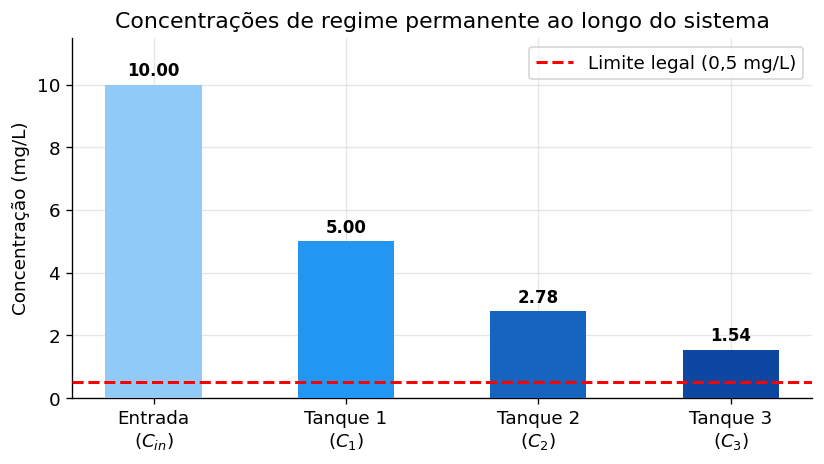

In [57]:
# ── Exercício 2b — Visualização dos resultados ─────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

tanques = ['Entrada\n($C_{in}$)', 'Tanque 1\n($C_1$)', 'Tanque 2\n($C_2$)', 'Tanque 3\n($C_3$)']
valores = [Cin] + list(C_gauss)
cores_bar = ['#90CAF9', '#2196F3', '#1565C0', '#0D47A1']

bars = ax.bar(tanques, valores, color=cores_bar, width=0.5, zorder=3)
ax.axhline(0.5, color='red', ls='--', lw=1.8, label='Limite legal (0,5 mg/L)', zorder=4)

for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.15,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Concentração (mg/L)')
ax.set_title('Concentrações de regime permanente ao longo do sistema')
ax.set_ylim(0, Cin * 1.15)
ax.legend()
plt.tight_layout()
plt.show()


---
## 5. Parte 2 — Encontrando o $k$ mínimo: zeros de função

### O problema do gestor

O coeficiente $k$ não é uma constante absoluta: ele depende da temperatura, do tipo de microrganismo
e das condições do reator. No inverno, $k$ pode cair. Você precisa saber:

> **Qual é o valor mínimo de $k$ que ainda mantém $C_3 \leq 0{,}5\ mg/L$?**

Abaixo desse valor crítico $k^*$, a planta está fora da lei e uma intervenção é necessária.

### Por que é um problema de raiz?

Da Parte 1, sabemos calcular $C_3$ para qualquer valor de $k$: basta montar e resolver o sistema linear. No entanto, **não existe uma fórmula fechada simples para $C_3$ em função de $k$** neste caso, pois $C_3$ depende do resultado da solução do sistema de equações lineares, que envolve todos os parâmetros do sistema (volumes, vazão, entrada, etc). Por isso, precisamos de um procedimento numérico: para cada valor de $k$, resolvemos o sistema e obtemos $C_3$.

Dizemos então que $C_3$ é uma **função de $k$**, mesmo que não tenhamos uma expressão explícita para ela. Podemos representá-la como $C_3(k)$, entendendo que, para cada valor de $k$, existe um valor correspondente de $C_3$ calculado numericamente.

Queremos encontrar o valor de $k$ tal que $C_3$ atinja exatamente o limite legal. Para isso, definimos a função

$$f(k) = C_3(k) - 0{,}5$$

Ou seja, $f(k)$ mede a diferença entre a concentração de saída e o limite legal. O valor de $k$ que zera essa função ($f(k^*) = 0$) é o valor mínimo de $k$ que garante a conformidade. Como não temos uma fórmula fechada para $C_3(k)$, usamos métodos numéricos (como a bisseção) para encontrar a raiz de $f(k)$.


### 🔧 Exercício 3 — Defina $C_3(k)$ e explore graficamente

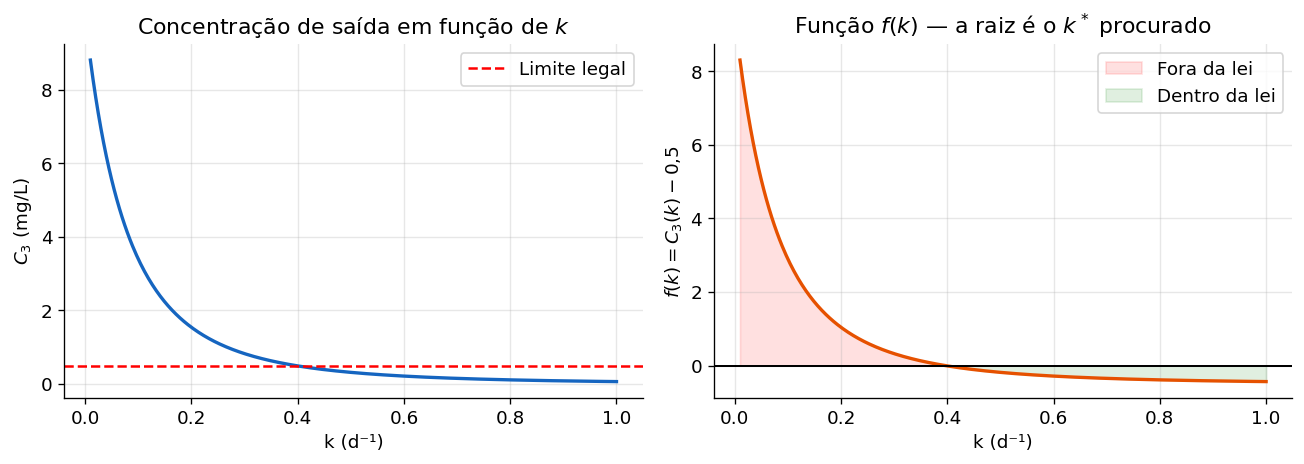

Questões para reflexão:
  1. f(k) é crescente ou decrescente? Por quê isso faz sentido fisicamente?
  2. Em qual intervalo aproximado está a raiz k*?


In [58]:
# ── Exercício 3 ────────────────────────────────────────────────────────
def C3_de_k(k_val, Q=Q, V1=V1, V2=V2, V3=V3, Cin=Cin):
    """
    Retorna a concentração de saída C₃ em regime permanente,
    para um dado valor de k, resolvendo o sistema linear Ax = b.
    """
    tau1, tau2, tau3 = Q/V1, Q/V2, Q/V3

    A_k = np.array([
        [ tau1 + k_val,           0,           0],
        [-tau2        , tau2+k_val,           0],
        [ 0           ,     -tau3 , tau3+k_val],
    ])
    b_k = np.array([tau1 * Cin, 0.0, 0.0])

    return np.linalg.solve(A_k, b_k)[2]

def f(k_val):
    return C3_de_k(k_val) - 0.5

# Intervalo de k para explorar
k_vals = np.linspace(0.01, 1.0, 400)
f_vals = np.array([f(k) for k in k_vals])

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Esquerda: C₃(k)
ax = axes[0]
ax.plot(k_vals, [C3_de_k(k) for k in k_vals], '#1565C0', lw=2)
ax.axhline(0.5, color='red', ls='--', lw=1.5, label='Limite legal')
ax.set_xlabel('k (d⁻¹)')
ax.set_ylabel('$C_3$ (mg/L)')
ax.set_title('Concentração de saída em função de $k$')
ax.legend()

# Direita: f(k) = C₃(k) − 0,5
ax = axes[1]
ax.plot(k_vals, f_vals, '#E65100', lw=2)
ax.axhline(0, color='black', lw=1.2)
ax.fill_between(k_vals, f_vals, 0,
                where=(f_vals > 0), alpha=0.12, color='red',   label='Fora da lei')
ax.fill_between(k_vals, f_vals, 0,
                where=(f_vals < 0), alpha=0.12, color='green', label='Dentro da lei')
ax.set_xlabel('k (d⁻¹)')
ax.set_ylabel('$f(k) = C_3(k) - 0{,}5$')
ax.set_title('Função $f(k)$ — a raiz é o $k^*$ procurado')
ax.legend()

plt.tight_layout()
plt.show()

print("Questões para reflexão:")
print("  1. f(k) é crescente ou decrescente? Por quê isso faz sentido fisicamente?")
print("  2. Em qual intervalo aproximado está a raiz k*?")


### 🔧 Exercício 4 — Método da Bisseção

In [59]:
# ── Exercício 4 — Bisseção ─────────────────────────────────────────────
def bissecao(f, a, b, tol=1e-4, max_iter=100):
    """
    Encontra a raiz de f no intervalo [a, b] pelo Método da Bisseção.
    Retorna (raiz, histórico de iterações).
    """
    assert f(a) * f(b) < 0, "f(a) e f(b) devem ter sinais opostos!"
    historico = []
    c = (a + b) / 2  # inicializa c para garantir que sempre exista

    for i in range(1, max_iter + 1):
        c = (a + b) / 2
        historico.append({'iter': i, 'a': a, 'b': b, 'c': c,
                          'f(c)': f(c), 'erro': (b - a) / 2})
        if abs(f(c)) < tol or (b - a) / 2 < tol:
            break
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c

    return c, historico

k_star, hist = bissecao(f, a=0.01, b=1.0, tol=1e-4)

print(f"Raiz encontrada: k* ≈ {k_star:.6f} d⁻¹")
print(f"C₃(k*) = {C3_de_k(k_star):.6f} mg/L")
print(f"Iterações realizadas: {len(hist)}")
print()

# Tabela de iterações
print(f"{'Iter':>4}  {'a':>10}  {'b':>10}  {'c':>10}  {'f(c)':>12}  {'Erro':>12}")
print("-" * 64)
for h in hist:
    print(f"{h['iter']:>4}  {h['a']:>10.6f}  {h['b']:>10.6f}  "
          f"{h['c']:>10.6f}  {h['f(c)']:>12.6f}  {h['erro']:>12.6f}")


Raiz encontrada: k* ≈ 0.397081 d⁻¹
C₃(k*) = 0.499987 mg/L
Iterações realizadas: 13

Iter           a           b           c          f(c)          Erro
----------------------------------------------------------------
   1    0.010000    1.000000    0.505000     -0.188952      0.495000
   2    0.010000    0.505000    0.257500      0.560833      0.247500
   3    0.257500    0.505000    0.381250      0.039690      0.123750
   4    0.381250    0.505000    0.443125     -0.095432      0.061875
   5    0.381250    0.443125    0.412187     -0.034346      0.030938
   6    0.381250    0.412187    0.396719      0.000852      0.015469
   7    0.396719    0.412187    0.404453     -0.017174      0.007734
   8    0.396719    0.404453    0.400586     -0.008271      0.003867
   9    0.396719    0.400586    0.398652     -0.003738      0.001934
  10    0.396719    0.398652    0.397686     -0.001450      0.000967
  11    0.396719    0.397686    0.397202     -0.000301      0.000483
  12    0.396719    0.3

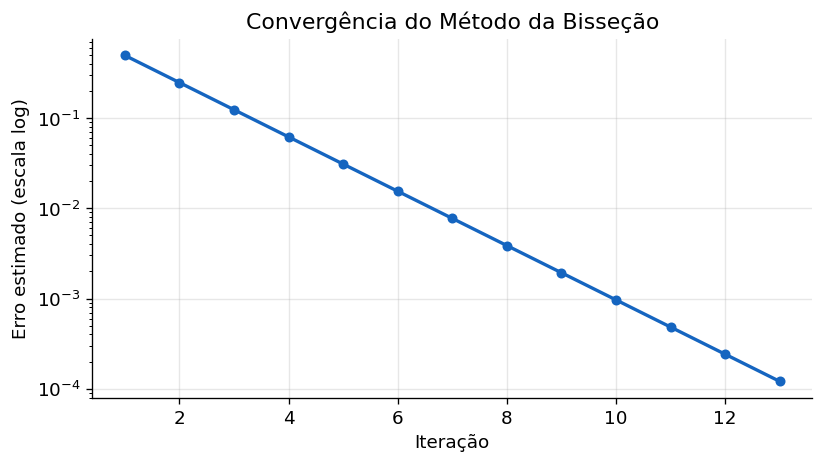

In [60]:
# Convergência da bisseção
erros = [h['erro'] for h in hist]
iters = [h['iter'] for h in hist]

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(iters, erros, 'o-', color='#1565C0', lw=2, ms=5)
ax.set_xlabel('Iteração')
ax.set_ylabel('Erro estimado (escala log)')
ax.set_title('Convergência do Método da Bisseção')
plt.tight_layout()
plt.show()


### 🔧 Exercício 5 — Método de Newton-Raphson *(desafio)*

O Método de Newton-Raphson exige a derivada de $f$. Aqui, usaremos uma **derivada numérica** (diferenças finitas centrais), que você estudará mais adiante — por ora, confie na implementação.

In [61]:
# ── Exercício 5 — Newton-Raphson ───────────────────────────────────────
def derivada_numerica(f, x, h=1e-6):
    """Derivada por diferenças finitas centrais."""
    return (f(x + h) - f(x - h)) / (2 * h)

def newton_raphson(f, x0, tol=1e-4, max_iter=50):
    """
    Encontra a raiz de f pelo Método de Newton-Raphson.
    Retorna (raiz, histórico).
    """
    x = x0
    historico = []

    for i in range(1, max_iter + 1):
        fx  = f(x)
        dfx = derivada_numerica(f, x)
        if dfx == 0:
            raise ZeroDivisionError("Derivada nula — método falhou.")
        x_novo = x - fx / dfx
        historico.append({'iter': i, 'x': x, 'f(x)': fx,
                          "f'(x)": dfx, 'x_novo': x_novo,
                          'erro': abs(x_novo - x)})
        if abs(x_novo - x) < tol:
            x = x_novo
            break
        x = x_novo

    return x, historico

k_nr, hist_nr = newton_raphson(f, x0=0.1, tol=1e-4)

print(f"Raiz encontrada: k* ≈ {k_nr:.6f} d⁻¹")
print(f"C₃(k*) = {C3_de_k(k_nr):.6f} mg/L")
print(f"Iterações realizadas: {len(hist_nr)}")
print()

print(f"{'Iter':>4}  {'x':>10}  {'f(x)':>12}  {'x_novo':>10}  {'Erro':>12}")
print("-" * 56)
for h in hist_nr:
    print(f"{h['iter']:>4}  {h['x']:>10.6f}  {h['f(x)']:>12.6f}  "
          f"{h['x_novo']:>10.6f}  {h['erro']:>12.6f}")


Raiz encontrada: k* ≈ 0.397076 d⁻¹
C₃(k*) = 0.500000 mg/L
Iterações realizadas: 6

Iter           x          f(x)      x_novo          Erro
--------------------------------------------------------
   1    0.100000      2.901361    0.194279      0.094279
   2    0.194279      1.106183    0.292135      0.097856
   3    0.292135      0.364196    0.365797      0.073662
   4    0.365797      0.082606    0.394068      0.028271
   5    0.394068      0.007237    0.397047      0.002979
   6    0.397047      0.000068    0.397076      0.000029


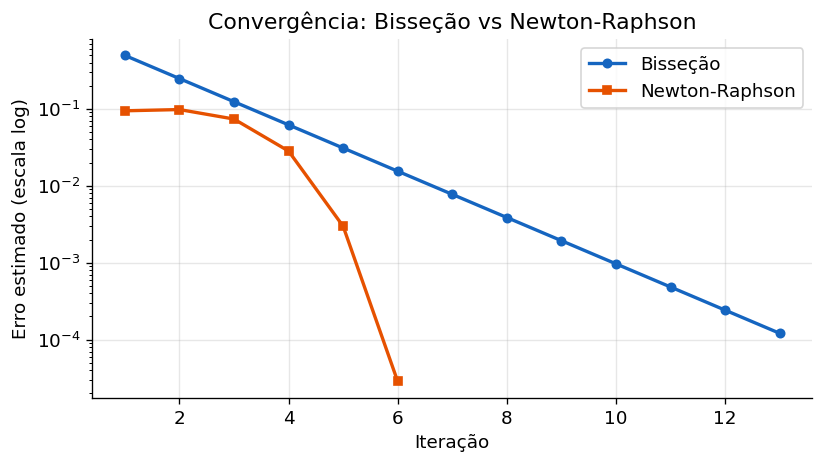

Bisseção:         13 iterações  →  k* = 0.397081 d⁻¹
Newton-Raphson:    6 iteração(ões) →  k* = 0.397076   d⁻¹


In [62]:
# Comparação de convergência: Bisseção vs Newton-Raphson
fig, ax = plt.subplots(figsize=(7, 4))

ax.semilogy([h['iter'] for h in hist],    [h['erro'] for h in hist],
            'o-', color='#1565C0', lw=2, ms=5, label='Bisseção')
ax.semilogy([h['iter'] for h in hist_nr], [h['erro'] for h in hist_nr],
            's-', color='#E65100', lw=2, ms=5, label='Newton-Raphson')

ax.set_xlabel('Iteração')
ax.set_ylabel('Erro estimado (escala log)')
ax.set_title('Convergência: Bisseção vs Newton-Raphson')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Bisseção:        {len(hist):>3} iterações  →  k* = {k_star:.6f} d⁻¹")
print(f"Newton-Raphson:  {len(hist_nr):>3} iteração(ões) →  k* = {k_nr:.6f}   d⁻¹")


---
## 6. Para pensar além

### 6.1 — Reciclo

Suponha que 10 % do efluente do Tanque 3 seja recirculado de volta ao Tanque 1
(técnica comum para aumentar a biomassa ativa). A concentração efetiva na entrada do Tanque 1 passa a ser:

$$C_{0,\text{efetivo}} = \frac{Q\,C_{in} + 0{,}1\,Q\,C_3}{Q + 0{,}1\,Q} = \frac{C_{in} + 0{,}1\,C_3}{1{,}1}$$

Como $C_3$ aparece dos dois lados do sistema, a matriz $A$ **deixa de ser triangular**:
a equação do Tanque 1 passa a depender de $C_3$, e vice-versa.

**Reflita:** como você montaria a nova matriz $A$ nesse caso? Implemente e compare os resultados com o sistema sem reciclo.

---

### 6.2 — Sazonalidade

A constante $k$ varia com a temperatura segundo a equação de Arrhenius simplificada:

$$k(T) = k_{20} \cdot \theta^{\,T - 20}, \qquad \theta \approx 1{,}072$$

onde $T$ é a temperatura da água em °C e $k_{20}$ é o valor de referência a 20 °C.

**Reflita:** dado o valor $k^*$ encontrado na Parte 2, qual é a temperatura mínima da água que ainda
mantém a planta dentro da lei? Use o Método da Bisseção para encontrar essa temperatura.

---

### 6.3 — O transitório (próximos módulos)

Quando o sistema é ligado com os tanques vazios ($C_i(0) = 0$), quanto tempo leva até
$C_3(t)$ se aproximar do valor de regime permanente calculado na Parte 1?

Essa pergunta só pode ser respondida resolvendo as EDOs — e é exatamente o que faremos
nos próximos módulos, com os métodos de Euler e Runge-Kutta.


In [63]:
# ── Seção 6.1 — Espaço para exploração do reciclo ─────────────────────
# Complete aqui a montagem do sistema com reciclo.

# Dica: defina alpha = 0.10 (fração de reciclo)
# e reescreva A e b considerando que C₀_efetivo depende de C₃.

alpha = 0.10

# A = ???
# b = ???
# C_reciclo = np.linalg.solve(A, b)


---
## Resumo do que foi feito

| Etapa | Problema | Ferramenta |
|---|---|---|
| Modelagem | Balanço de massa em cada tanque | EDO |
| Regime permanente | $dC_i/dt = 0$ → equações algébricas | Sistema linear $A\mathbf{x} = \mathbf{b}$ |
| Solução do sistema | Concentrações $C_1$, $C_2$, $C_3$ | Eliminação de Gauss |
| Projeto de conformidade | Encontrar $k^*$ tal que $C_3(k^*) = 0{,}5$ | Bisseção / Newton-Raphson |

O fio condutor desta atividade é a transição natural entre os métodos:
a física gera EDOs → simplificação gera álgebra linear → pergunta de projeto gera zero de função.
Cada etapa motiva a seguinte.
